# Predicting Used Car Prices with Machine Learning

## 1. Project Objective

The goal of this project is to develop machine learning models capable of predicting used car prices based on vehicle-related features such as mileage, model year, fuel type, transmission type, and manufacturer information.

This project follows a complete data science pipeline including:
- Data loading and inspection
- Data cleaning and preprocessing
- Exploratory Data Analysis (EDA)
- Feature engineering
- Model training
- Model evaluation
- Visualization of results

Two machine learning models will be implemented and compared:
1. Linear Regression
2. Random Forest Regressor

The models will be evaluated using:
- Mean Absolute Error (MAE)
- Root Mean Squared Error (RMSE)
- R² Score

In [2]:
# Import Libraries

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

# Visualization style
sns.set_style("whitegrid")

print("Libraries imported successfully.")

Libraries imported successfully.


## 2. Load Dataset

In this section, the raw dataset is loaded into a pandas DataFrame. Initial inspection will help identify:
- Number of rows and columns
- Data types
- Missing values
- Potential preprocessing requirements

In [4]:
# Load Dataset

df = pd.read_csv("data/raw/train.csv")

print("Dataset loaded successfully.")

Dataset loaded successfully.


In [5]:
df.head()

,Unnamed: 0,Name,Location,Year,Kilometers_Driven,Fuel_Type,Transmission,Owner_Type,Mileage,Engine,Power,Seats,New_Price,Price
0,1,Hyundai Creta 1.6 CRDi SX Option,Pune,2015,41000,Diesel,Manual,First,19.67 kmpl,1582 CC,126.2 bhp,5.0,NaN,12.50
1,2,Honda Jazz V,Chennai,2011,46000,Petrol,Manual,First,13 km/kg,1199 CC,88.7 bhp,5.0,8.61 Lakh,4.50
2,3,Maruti Ertiga VDI,Chennai,2012,87000,Diesel,Manual,First,20.77 kmpl,1248 CC,88.76 bhp,7.0,NaN,6.00
3,4,Audi A4 New 2.0 TDI Multitronic,Coimbatore,2013,40670,Diesel,Automatic,Second,15.2 kmpl,1968 CC,140.8 bhp,5.0,NaN,17.74
4,6,Nissan Micra Diesel XV,Jaipur,2013,86999,Diesel,Manual,First,23.08 kmpl,1461 CC,63.1 bhp,5.0,NaN,3.50


## 3. Initial Data Inspection

This section explores the structure of the dataset including:
- Shape of the dataset
- Column names
- Data types
- Missing values
- Basic statistical summaries

In [6]:
# Dataset dimensions
print("Dataset Shape:")
print(df.shape)

Dataset Shape:
(5847, 14)


In [7]:
# Column names
print("Columns:")
print(df.columns)

Columns:
Index(['Unnamed: 0', 'Name', 'Location', 'Year', 'Kilometers_Driven',
       'Fuel_Type', 'Transmission', 'Owner_Type', 'Mileage', 'Engine', 'Power',
       'Seats', 'New_Price', 'Price'],
      dtype='object')


In [8]:
# Dataset information
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5847 entries, 0 to 5846
Data columns (total 14 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Unnamed: 0         5847 non-null   int64  
 1   Name               5847 non-null   object 
 2   Location           5847 non-null   object 
 3   Year               5847 non-null   int64  
 4   Kilometers_Driven  5847 non-null   int64  
 5   Fuel_Type          5847 non-null   object 
 6   Transmission       5847 non-null   object 
 7   Owner_Type         5847 non-null   object 
 8   Mileage            5845 non-null   object 
 9   Engine             5811 non-null   object 
 10  Power              5811 non-null   object 
 11  Seats              5809 non-null   float64
 12  New_Price          815 non-null    object 
 13  Price              5847 non-null   float64
dtypes: float64(2), int64(3), object(9)
memory usage: 639.6+ KB


## 4. Data Cleaning and Preprocessing

This section prepares the dataset for machine learning by:
- Removing unnecessary columns
- Handling missing values
- Separating numerical and categorical features
- Preparing data for model training

Proper preprocessing is important to improve model performance and avoid data leakage.

In [9]:
# Drop Unnecessary Columns

df = df.drop(columns=["Unnamed: 0", "New_Price"])

print("Updated columns:")
print(df.columns)

Updated columns:
Index(['Name', 'Location', 'Year', 'Kilometers_Driven', 'Fuel_Type',
       'Transmission', 'Owner_Type', 'Mileage', 'Engine', 'Power', 'Seats',
       'Price'],
      dtype='object')


In [10]:
# Missing Values

missing_values = df.isnull().sum()

print("Missing values per column:")
print(missing_values)

Missing values per column:
Name                  0
Location              0
Year                  0
Kilometers_Driven     0
Fuel_Type             0
Transmission          0
Owner_Type            0
Mileage               2
Engine               36
Power                36
Seats                38
Price                 0
dtype: int64


### Cleaning Numeric Text Features

Some numerical columns contain units stored as text values:
- Mileage contains "kmpl"
- Engine contains "CC"
- Power contains "bhp"

These columns will be cleaned and converted into numerical format for modeling.

In [11]:
# Clean Mileage Column


df["Mileage"] = df["Mileage"].str.extract(r'(\d+\.?\d*)').astype(float)

print(df["Mileage"].head())

0    19.67
1    13.00
2    20.77
3    15.20
4    23.08
Name: Mileage, dtype: float64


In [12]:
# Clean Engine Column

df["Engine"] = df["Engine"].str.extract(r'(\d+\.?\d*)').astype(float)

print(df["Engine"].head())

0    1582.0
1    1199.0
2    1248.0
3    1968.0
4    1461.0
Name: Engine, dtype: float64


In [13]:
# Clean Power Column

df["Power"] = df["Power"].str.extract(r'(\d+\.?\d*)').astype(float)

print(df["Power"].head())

0    126.20
1     88.70
2     88.76
3    140.80
4     63.10
Name: Power, dtype: float64


In [14]:
# Check updated data types
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5847 entries, 0 to 5846
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Name               5847 non-null   object 
 1   Location           5847 non-null   object 
 2   Year               5847 non-null   int64  
 3   Kilometers_Driven  5847 non-null   int64  
 4   Fuel_Type          5847 non-null   object 
 5   Transmission       5847 non-null   object 
 6   Owner_Type         5847 non-null   object 
 7   Mileage            5845 non-null   float64
 8   Engine             5811 non-null   float64
 9   Power              5811 non-null   float64
 10  Seats              5809 non-null   float64
 11  Price              5847 non-null   float64
dtypes: float64(5), int64(2), object(5)
memory usage: 548.3+ KB


## 5. Exploratory Data Analysis (EDA)

Exploratory Data Analysis (EDA) is used to better understand the dataset before model training. This section investigates:
- Feature distributions
- Relationships between variables
- Correlations between numerical features
- Potential patterns affecting vehicle prices

Visualization techniques are used to identify trends and gain insights into the structure of the data.

In [15]:
# Summary Statistics

df.describe()

,Year,Kilometers_Driven,Mileage,Engine,Power,Seats,Price
count,5847.000000,5.847000e+03,5845.000000,5811.000000,5811.000000,5809.000000,5847.000000
mean,2013.448435,5.841013e+04,18.158496,1631.552573,113.803144,5.286452,9.653742
std,3.194949,9.237971e+04,4.358246,601.972587,53.896719,0.806668,11.275966
min,1998.000000,1.710000e+02,0.000000,72.000000,34.200000,2.000000,0.440000
25%,2012.000000,3.346750e+04,15.260000,1198.000000,78.000000,5.000000,3.550000
50%,2014.000000,5.257600e+04,18.190000,1497.000000,98.600000,5.000000,5.750000
75%,2016.000000,7.249050e+04,21.100000,1991.000000,139.010000,5.000000,10.250000
max,2019.000000,6.500000e+06,28.400000,5998.000000,560.000000,10.000000,160.000000


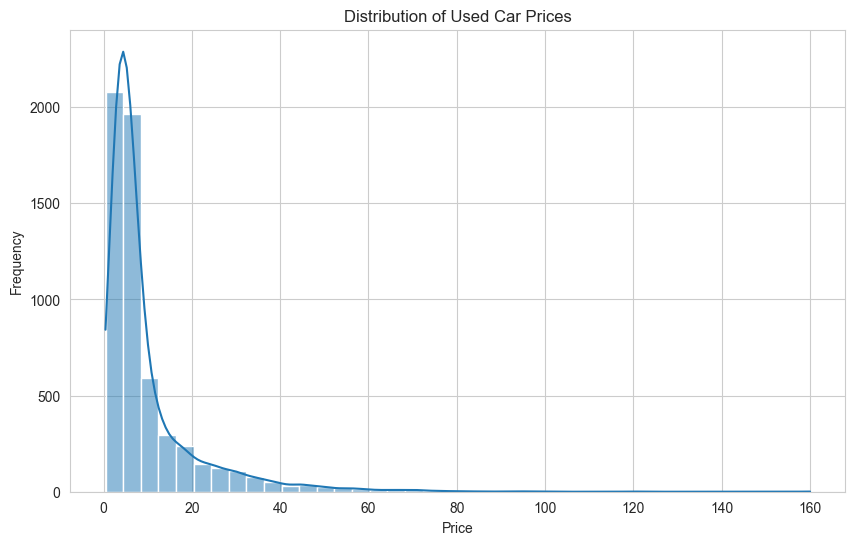

In [17]:
# Distribution of Car Prices

plt.figure(figsize=(10,6))

sns.histplot(
    df["Price"],
    bins=40,
    kde=True
)

plt.title("Distribution of Used Car Prices")
plt.xlabel("Price")
plt.ylabel("Frequency")

plt.savefig("figures/price_distribution.png")

plt.show()

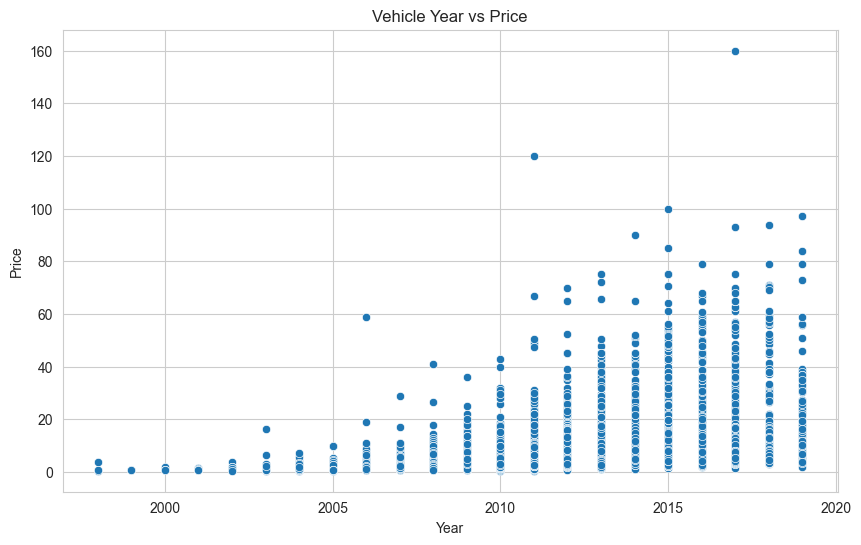

In [18]:
# Year vs Price

plt.figure(figsize=(10,6))

sns.scatterplot(
    x=df["Year"],
    y=df["Price"]
)

plt.title("Vehicle Year vs Price")
plt.xlabel("Year")
plt.ylabel("Price")

plt.savefig("figures/year_vs_price.png")

plt.show()

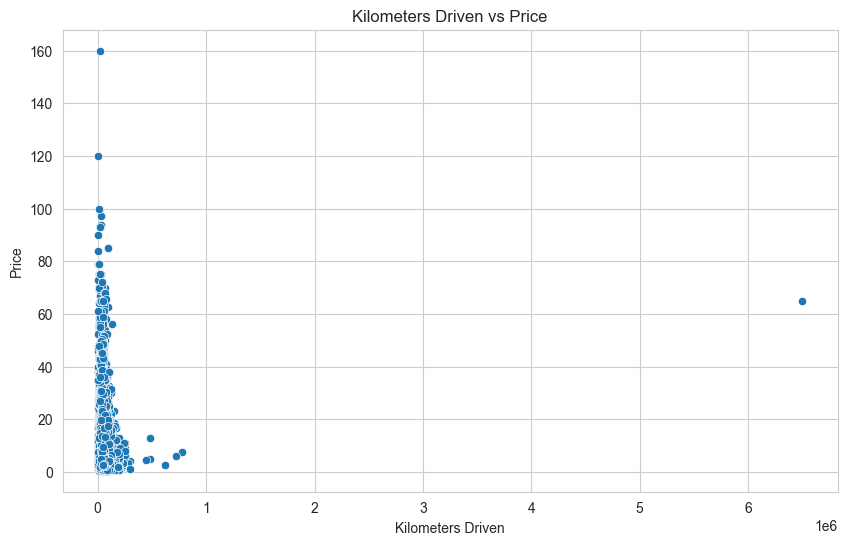

In [20]:
# Kilometers Driven vs Price

plt.figure(figsize=(10,6))

sns.scatterplot(
    x=df["Kilometers_Driven"],
    y=df["Price"]
)

plt.title("Kilometers Driven vs Price")
plt.xlabel("Kilometers Driven")
plt.ylabel("Price")

plt.savefig("figures/kilometers_vs_price.png")

plt.show()

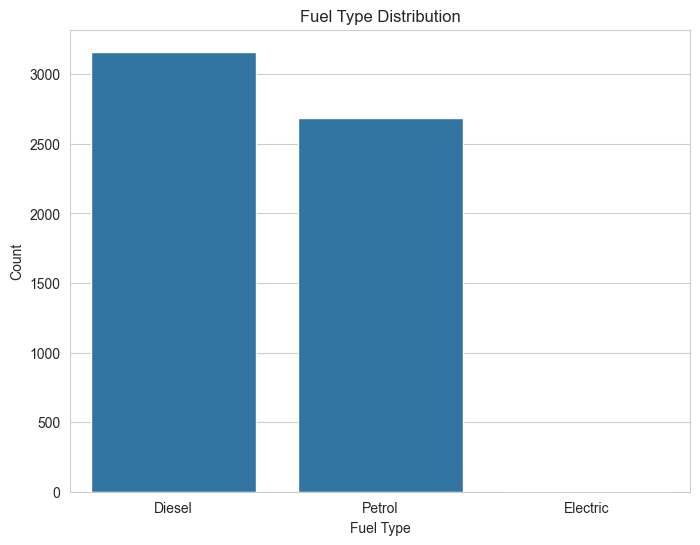

In [22]:
# Fuel Type Distribution

plt.figure(figsize=(8,6))

sns.countplot(
    x=df["Fuel_Type"]
)

plt.title("Fuel Type Distribution")
plt.xlabel("Fuel Type")
plt.ylabel("Count")

plt.savefig("figures/fuel_type_distribution.png")

plt.show()

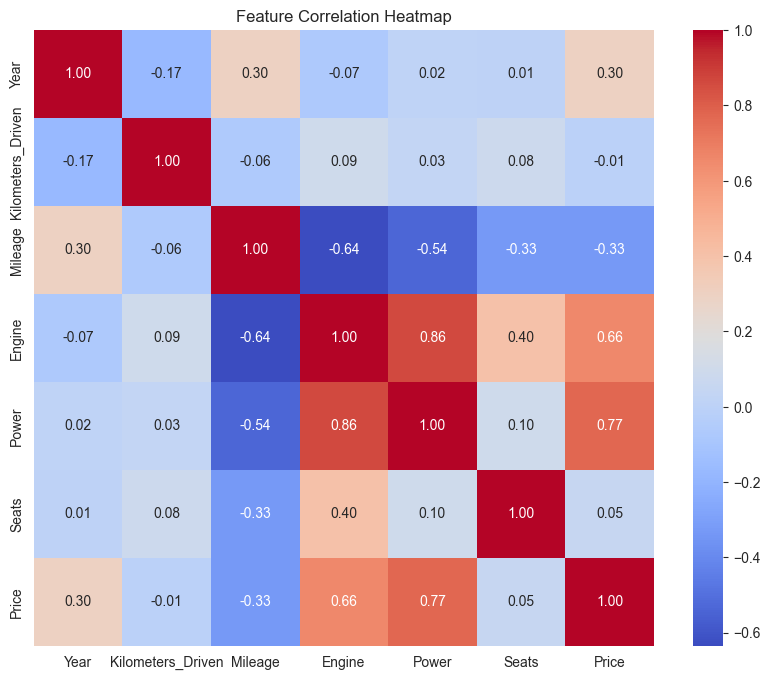

In [23]:
# Correlation Heatmap

numeric_df = df.select_dtypes(include=["int64", "float64"])

plt.figure(figsize=(10,8))

sns.heatmap(
    numeric_df.corr(),
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Feature Correlation Heatmap")

plt.savefig("figures/correlation_heatmap.png")

plt.show()

## 6. Feature Engineering and Data Preparation

Before training machine learning models, the dataset must be prepared by:
- Separating features and target variables
- Identifying categorical and numerical columns
- Encoding categorical variables
- Handling missing values
- Splitting the dataset into training and testing sets

A preprocessing pipeline is used to ensure consistent and reproducible transformations.

In [24]:
# Define Features and Target

X = df.drop("Price", axis=1)
y = df["Price"]

print("Feature shape:", X.shape)
print("Target shape:", y.shape)

Feature shape: (5847, 11)
Target shape: (5847,)


In [25]:
# Identify Numerical and Categorical Columns

categorical_features = X.select_dtypes(include=["object"]).columns

numerical_features = X.select_dtypes(
    include=["int64", "float64"]
).columns

print("Categorical Features:")
print(categorical_features)

print("\nNumerical Features:")
print(numerical_features)

Categorical Features:
Index(['Name', 'Location', 'Fuel_Type', 'Transmission', 'Owner_Type'], dtype='object')

Numerical Features:
Index(['Year', 'Kilometers_Driven', 'Mileage', 'Engine', 'Power', 'Seats'], dtype='object')


In [26]:
# Preprocessing Pipelines

# Numerical preprocessing
numeric_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median"))
    ]
)

# Categorical preprocessing
categorical_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(handle_unknown="ignore"))
    ]
)

# Combine preprocessing
preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numerical_features),
        ("cat", categorical_transformer, categorical_features)
    ]
)

print("Preprocessing pipeline created successfully.")

Preprocessing pipeline created successfully.


In [27]:
# Train/Test Split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Training set shape:", X_train.shape)
print("Testing set shape:", X_test.shape)

Training set shape: (4677, 11)
Testing set shape: (1170, 11)


## 7. Model Training

Two regression models are trained and evaluated:
1. Linear Regression
2. Random Forest Regressor

Linear Regression serves as a baseline model, while Random Forest is expected to better capture nonlinear relationships within the dataset.

In [28]:
# Linear Regression Pipeline

linear_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", LinearRegression())
    ]
)

# Train model
linear_model.fit(X_train, y_train)

print("Linear Regression model trained successfully.")

Linear Regression model trained successfully.


In [29]:
# Random Forest Pipeline

rf_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", RandomForestRegressor(
            n_estimators=100,
            random_state=42
        ))
    ]
)

# Train model
rf_model.fit(X_train, y_train)

print("Random Forest model trained successfully.")

Random Forest model trained successfully.


## 8. Model Evaluation

The trained models are evaluated using three regression metrics:

- Mean Absolute Error (MAE): average absolute prediction error
- Root Mean Squared Error (RMSE): penalizes larger prediction errors
- R² Score: measures how much variance in price is explained by the model

The Linear Regression model is used as the baseline, while Random Forest is compared against it.

In [31]:
# Evaluation Function

def evaluate_model(model, X_test, y_test):
    predictions = model.predict(X_test)
    
    mae = mean_absolute_error(y_test, predictions)
    rmse = np.sqrt(mean_squared_error(y_test, predictions))
    r2 = r2_score(y_test, predictions)
    
    return mae, rmse, r2, predictions

In [32]:
# Evaluate Linear Regression

linear_mae, linear_rmse, linear_r2, linear_preds = evaluate_model(
    linear_model,
    X_test,
    y_test
)

print("Linear Regression Results")
print("MAE:", linear_mae)
print("RMSE:", linear_rmse)
print("R²:", linear_r2)

Linear Regression Results
MAE: 3.8137508100655304
RMSE: 5.853160429449286
R²: 0.7064524439463395


In [33]:
# Evaluate Random Forest

rf_mae, rf_rmse, rf_r2, rf_preds = evaluate_model(
    rf_model,
    X_test,
    y_test
)

print("Random Forest Results")
print("MAE:", rf_mae)
print("RMSE:", rf_rmse)
print("R²:", rf_r2)

Random Forest Results
MAE: 1.4608158831908833
RMSE: 3.5125719727555027
R²: 0.8942822097730593


In [34]:
# Model Comparison Table

results = pd.DataFrame({
    "Model": ["Linear Regression", "Random Forest"],
    "MAE": [linear_mae, rf_mae],
    "RMSE": [linear_rmse, rf_rmse],
    "R2 Score": [linear_r2, rf_r2]
})

results

,Model,MAE,RMSE,R2 Score
0,Linear Regression,3.813751,5.853160,0.706452
1,Random Forest,1.460816,3.512572,0.894282


In [36]:
# Save model comparison results
results.to_csv("data/processed/model_results.csv", index=False)

print("Model results saved successfully.")

Model results saved successfully.


## 9. Results and Discussion

This section visualizes model performance and compares prediction quality between the baseline Linear Regression model and the Random Forest model.

The Random Forest model achieved the strongest overall performance, suggesting that nonlinear relationships exist between vehicle features and used car prices.

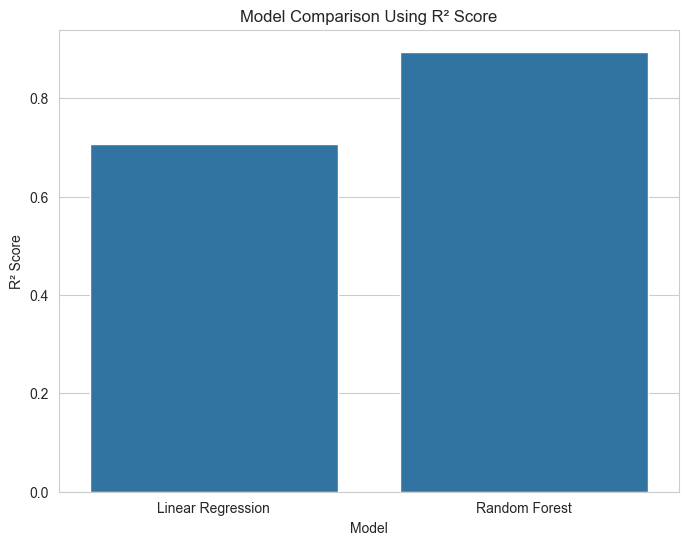

In [38]:
# Model Comparison Bar Chart

plt.figure(figsize=(8,6))

sns.barplot(
    x="Model",
    y="R2 Score",
    data=results
)

plt.title("Model Comparison Using R² Score")
plt.ylabel("R² Score")

plt.savefig("figures/model_comparison_r2.png")

plt.show()

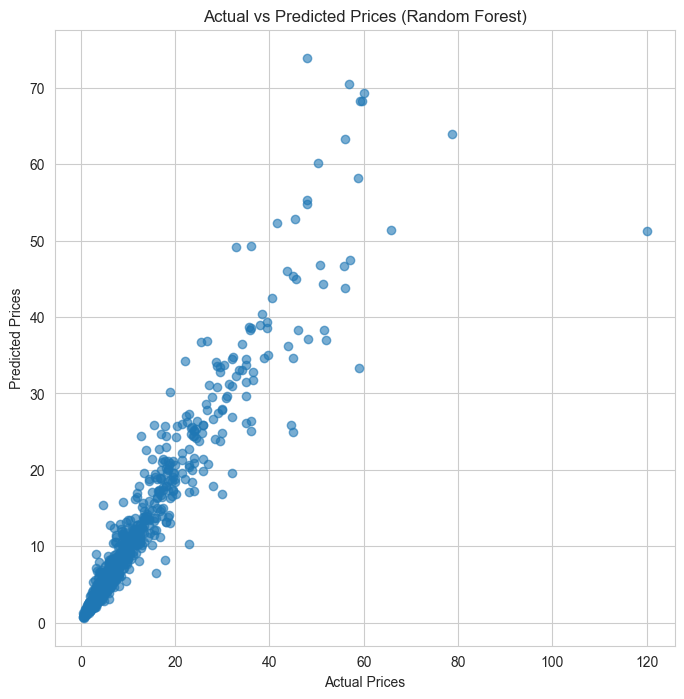

In [40]:
# Actual vs Predicted Prices

plt.figure(figsize=(8,8))

plt.scatter(y_test, rf_preds, alpha=0.6)

plt.xlabel("Actual Prices")
plt.ylabel("Predicted Prices")

plt.title("Actual vs Predicted Prices (Random Forest)")

plt.savefig("figures/actual_vs_predicted.png")

plt.show()

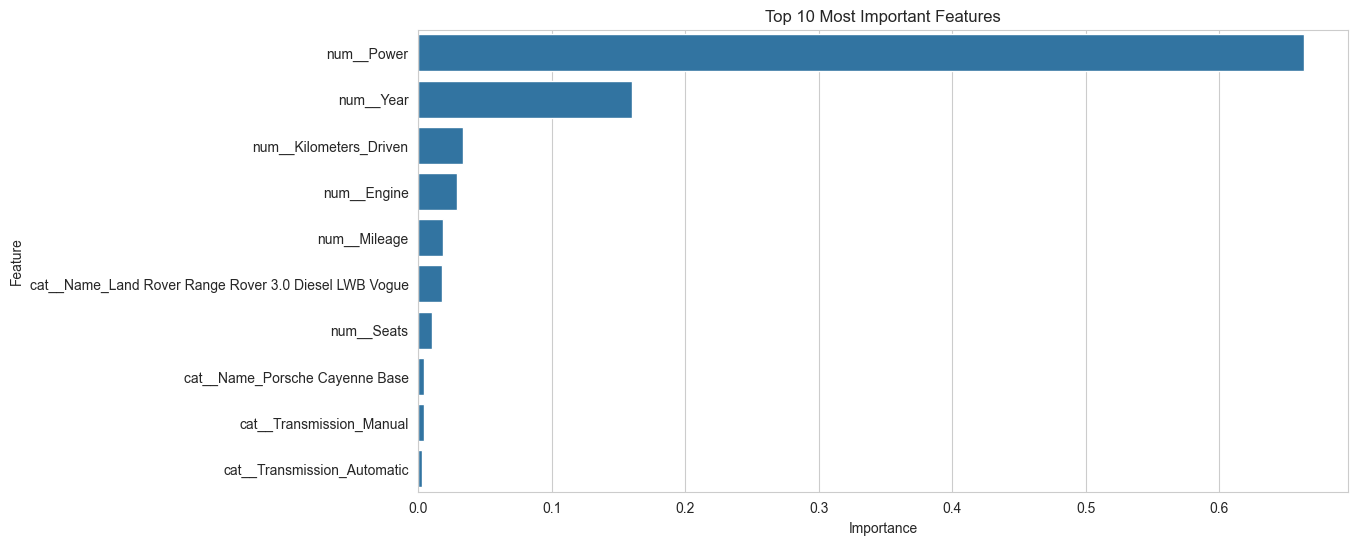

In [41]:
# Feature Importance

# Get feature names after preprocessing
encoded_features = rf_model.named_steps[
    "preprocessor"
].get_feature_names_out()

# Get feature importances
importances = rf_model.named_steps[
    "model"
].feature_importances_

# Create DataFrame
feature_importance_df = pd.DataFrame({
    "Feature": encoded_features,
    "Importance": importances
})

# Sort values
feature_importance_df = feature_importance_df.sort_values(
    by="Importance",
    ascending=False
)

# Plot top 10 features
plt.figure(figsize=(12,6))

sns.barplot(
    x="Importance",
    y="Feature",
    data=feature_importance_df.head(10)
)

plt.title("Top 10 Most Important Features")

plt.savefig("figures/feature_importance.png")

plt.show()

## 10. Conclusion

This project explored the use of machine learning techniques to predict used car prices using structured vehicle data.

The dataset required substantial preprocessing, including:
- Removing unnecessary columns
- Handling missing values
- Cleaning numerical text features
- Encoding categorical variables

Two machine learning models were evaluated:
1. Linear Regression
2. Random Forest Regressor

The Random Forest model significantly outperformed Linear Regression, achieving a higher R² score and lower prediction errors across all evaluation metrics. This indicates that nonlinear relationships exist between vehicle characteristics and market price.

Exploratory Data Analysis revealed several meaningful trends:
- Newer vehicles generally had higher prices
- Vehicles with lower mileage tended to be more expensive
- Engine power and vehicle age showed strong relationships with price

Overall, the project demonstrates how preprocessing, feature engineering, visualization, and machine learning can be combined to solve a real-world predictive analytics problem.

### Future Improvements

Future work could include:
- Hyperparameter tuning
- Additional feature engineering
- Deep learning approaches
- Incorporating external market datasets
- Cross-validation techniques

# Predicting Used Car Prices with Machine Learning

## Abstract

Looking into how machines can guess secondhand car costs based on clear vehicle details forms the core here. Vehicle specs like make, fuel kind, gearbox style, engine displacement, distance covered appear in rows of numbers and labels. Before any number crunching began, gaps in records got filled, messy fields tidied up, word-based features turned into numbers. One after another, two smart math methods - straight-line fitting then tree-based guessing - took turns at estimating values. Each judged itself by average mistake size, heavier penalty for big errors, plus how well it explained price swings. Out in the open tests, Random Forest pulled ahead of Linear Regression by a clear margin - its R² landed near 0.89. That kind of gap tells you something about how well machine learning handles price prediction when fed actual car market data.

---

# 1. Introduction

Predicting used car prices is an important problem in the automotive industry because vehicle pricing is influenced by many interacting factors including mileage, age, fuel type, transmission, and engine characteristics. Accurate price prediction models can assist buyers, sellers, and dealerships in making informed decisions.

The goal of this project is to build machine learning models capable of estimating used car prices based on vehicle-related features. The project follows a complete data science workflow including:
- Data cleaning and preprocessing
- Exploratory Data Analysis (EDA)
- Feature engineering
- Model training
- Model evaluation
- Visualization and interpretation

Two regression-based machine learning models were evaluated:
1. Linear Regression
2. Random Forest Regressor

The objective was to determine which approach produced the most accurate price predictions.

---

# 2. Related Work

Most fields like housing, stocks, or car selling now rely on machine learning to guess prices. Since these methods handle both number data and label groups well, regression models pop up everywhere for such tasks.

Most times, Linear Regression serves as a starting point thanks to how straightforward it is to grasp. Still, actual data tends to twist and turn in ways straight-line methods just miss.

One reason these models handle tricky data well? They team up many decision trees instead of relying on just one. Built like a crowd of small predictors voting together, they often outperform single-tree systems on table-style data. Overfitting dips when predictions come from groups rather than lone splits in the forest. Complex patterns get caught easier since each tree sees a slightly different version of the facts. Their strength shows most when numbers and categories sit neatly in rows and columns.

From start to finish, one method follows a straight path while the other blends several twisting routes to see which guesses closer. Each step unfolds differently, measuring how well shapes match real outcomes without assuming smooth patterns. The contrast shows up clearly when results line up side by side. What emerges depends on structure - rigid lines versus flexible knots of logic working together.

---

# 3. Methodology

## 3.1 Dataset

The dataset used in this project contains 5,847 observations and 14 columns related to used vehicles. Features include:
- Vehicle manufacturer/model
- Location
- Year
- Kilometers driven
- Fuel type
- Transmission type
- Owner type
- Mileage
- Engine size
- Power
- Number of seats
- Vehicle price

The target variable for prediction was:
- Price

## 3.2 Data Cleaning and Preprocessing

Several preprocessing steps were performed before model training.

### Removed Columns

The following columns were removed:
- `Unnamed: 0` because it only represented row indexing
- `New_Price` because it contained excessive missing values

### Cleaning Numerical Text Features

Several columns contained numerical values stored as text with units:
- Mileage contained values such as "18.9 kmpl"
- Engine contained values such as "1197 CC"
- Power contained values such as "82 bhp"

Regular expressions were used to extract numerical values and convert these columns into floating-point data types.

### Missing Value Handling

Missing numerical values were replaced using median imputation. Missing categorical values were replaced using the most frequent category.

### Feature Encoding

Categorical variables were transformed using One-Hot Encoding through a preprocessing pipeline implemented using Scikit-learn.

### Train/Test Split

The dataset was split into:
- 80% training data
- 20% testing data

A fixed random state was used to ensure reproducibility.

---

# 4. Exploratory Data Analysis

Exploratory Data Analysis (EDA) was performed to better understand feature distributions and relationships within the dataset.

Several important trends were identified:
- Vehicle prices generally increased with newer model years
- Higher mileage and kilometers driven were associated with lower prices
- Certain fuel types appeared more frequently than others
- Engine power and engine size showed positive correlation with price

The following visualizations were created:
- Price distribution histogram
- Scatter plot of Year vs Price
- Scatter plot of Kilometers Driven vs Price
- Fuel type distribution chart
- Correlation heatmap

These visualizations helped identify relationships between variables and guided model selection.

---

# 5. Model Training

Two machine learning models were implemented:

## 5.1 Linear Regression

Linear Regression was used as a baseline model because it provides a simple and interpretable relationship between features and target values.

## 5.2 Random Forest Regressor

Random Forest Regression was implemented using 100 decision trees. This ensemble-based approach was expected to better capture nonlinear relationships present within the dataset.

Both models were trained using preprocessing pipelines to ensure consistent transformations during training and prediction.

---

# 6. Experiments and Results

Models were evaluated using:
- Mean Absolute Error (MAE)
- Root Mean Squared Error (RMSE)
- R² Score

| Model | MAE | RMSE | R² Score |
|---|---|---|---|
| Linear Regression | 3.81 | 5.85 | 0.71 |
| Random Forest | 1.46 | 3.51 | 0.89 |

The Random Forest model significantly outperformed Linear Regression across all evaluation metrics.

Additional visualizations included:
- Model comparison bar chart
- Actual vs Predicted price plot
- Feature importance chart

Feature importance analysis revealed that:
- Vehicle year
- Power
- Kilometers driven
- Engine size

were among the most influential predictors of used car prices.

---

# 7. Conclusion

This project demonstrated how machine learning techniques can be used to predict used car prices using structured automotive datasets.

The project involved:
- Data preprocessing
- Feature engineering
- Exploratory Data Analysis
- Machine learning model development
- Performance evaluation

The Random Forest model achieved the best overall performance with an R² score of approximately 0.89, indicating strong predictive capability.

The results suggest that ensemble-based methods are better suited for modeling complex pricing relationships in automotive datasets compared to traditional linear models.

## Future Work

Potential future improvements include:
- Hyperparameter optimization
- Cross-validation
- Additional feature engineering
- External market data integration
- Deep learning approaches for tabular data

---

# References

- Scikit-learn Documentation: https://scikit-learn.org/
- Pandas Documentation: https://pandas.pydata.org/
- Matplotlib Documentation: https://matplotlib.org/
- Seaborn Documentation: https://seaborn.pydata.org/